# B-8802B — o sistema de retreino funcionou? (jan/2025 a ago/2026)

**A política, em 4 linhas**
1. O modelo fica **fixo**. Toda semana o monitor compara a operação com o normal que o modelo aprendeu.
2. Se o normal mudou (por exemplo, depois de um reparo), o monitor **avisa** e a operação diz se é um normal novo.
3. Se for: com **1 mês** de dado novo entra um **modelo novo**, refeito todo mês até completar 12 meses.
4. Se não for (é defeito no equipamento): **não retreina**, porque o alerta é o que interessa.

**O teste:** rodamos essa política sobre os dados reais, como se ela estivesse em produção desde jan/2025, e comparamos
com o que teria acontecido se o modelo antigo (de 2022) tivesse ficado. Nesse período não houve falha no equipamento:
**todo alerta é falso**, então quanto menos alerta, melhor.

In [1]:
import sys, json, shutil, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import torch
%config InlineBackend.figure_format = "retina"
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DEP = PROJECT_ROOT / "deploy_v2/Transpetro"; sys.path.insert(0, str(DEP))
import simpred_inference as si
from transpetro_modelos.drift import monitor as mon
from transpetro_modelos.drift.detectors import CalibratedKSDetector
from transpetro_modelos.drift.residuo import ResidualLevelDetector

# modelos do replay: 12 retreinos mensais rodados no ClearML (scripts/replay_pipeline.py, task 28fb7c95);
# baixe com: python scripts/replay_pipeline.py --baixar 28fb7c95e4df46b38782472e1837f857 --out results/replay_pipeline
R = PROJECT_ROOT / "results/replay_pipeline"
DADOS = DEP / "B-8802B-2025/dados/2025_2026/data_2025-01-01_2026-08-10_raw.csv"
raw = si.carregar_dados(DADOS); FIM = raw.index.max()
B_ATUAL = DEP / "B-8802B-2025/modelos/model_2025-01-01_2026-08-10_VAE"

# o modelo de 2022 com as mesmas regras de alarme (persistência no tempo, regra de 1 h), numa cópia
B_ANTIGO = R / "modelo_2022_regras_novas"
if not B_ANTIGO.exists():
    shutil.copytree(DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE", B_ANTIGO)
alarm = json.loads((B_ANTIGO / "alarm.json").read_text())
alarm.update({"debounce_window": 20, "debounce_min": 15, "persistence_mode": "time", "persistence_step": "5min", "min_alert_hours": 1.0})
(B_ANTIGO / "alarm.json").write_text(json.dumps(alarm, indent=1, ensure_ascii=False))
resumo = pd.read_csv(R / "resumo.csv")

# quem esteve em produção e quando: o modelo de 2022 até o 1º retreino, depois cada retreino aprovado
agenda = [{"modelo": "2022", "bundle": B_ANTIGO, "ini": raw.index.min()}]
agenda += [{"modelo": f"{r.etapa} m", "bundle": PROJECT_ROOT / r.bundle, "ini": pd.Timestamp(r.treino_fim)}
           for r in resumo.itertuples() if r.aprovado]
for i, a in enumerate(agenda):
    a["fim"] = agenda[i + 1]["ini"] if i + 1 < len(agenda) else FIM

def roda(bundle, ini, fim):
    seg = raw.loc[ini - pd.Timedelta(days=1): fim]
    X = si.preprocessar(bundle, seg); m = si.carregar_modelo(bundle)
    r = si.prever(bundle, m, X, df_bruto=seg)
    torch.manual_seed(0)
    with torch.no_grad():
        rec = m(torch.tensor(X.values, dtype=torch.float32))[0].numpy()
    err = pd.DataFrame((rec - X.values) ** 2, index=X.index, columns=X.columns)
    sel = (r.index >= ini) & (r.index < fim)
    return r[sel], err[sel]

def episodios(flag, err):
    a = flag[flag]
    if a.empty: return []
    out = []
    for _, e in a.groupby((a.index.to_series().diff() > pd.Timedelta("1h")).cumsum()):
        w = err.loc[e.index.min() - pd.Timedelta(hours=2): e.index.max()].mean()
        out.append({"início": e.index.min(), "horas": round((e.index.max() - e.index.min()).total_seconds() / 3600 + 1 / 12, 1),
                    "sensor que mais pesou": w.idxmax()})
    return out

partes, eps = [], []
for a in agenda:
    r, err = roda(a["bundle"], a["ini"], a["fim"]); r["modelo"] = a["modelo"]; partes.append(r)
    eps += [dict(e, modelo=a["modelo"]) for e in episodios(r["alerta"], err)]
sistema = pd.concat(partes)                                    # o que o sistema com retreino teria feito
antigo, err_ant = roda(B_ANTIGO, raw.index.min(), FIM)          # se o modelo de 2022 tivesse ficado
eps_antigo = episodios(antigo["alerta"], err_ant)

t_drift = mon.ks_daily_fires(DADOS, DEP / "B-8802B/modelos/model_2022-05-15_2022-07-21_VAE")[0][0]    # aviso de 2025
d12 = agenda[-1]["bundle"]                                        # o modelo de 12 meses e o aviso de 2026 (M8)
todos = mon._sem_congelado(d12, mon._temporal_steps(d12, raw.loc[agenda[-1]["ini"]:], todos_sensores=True))
t_m8 = ResidualLevelDetector.from_dict(json.loads((d12 / "residual_ref.json").read_text())["detectors"][0]).scan(todos)[1][0]
print("pronto")

pronto


## O resultado em uma figura

Cada barra é uma semana: quanto daquela semana teve **alerta** (lembrando: nesse período todo alerta é falso).
**Cinza:** se o modelo de 2022 tivesse ficado. **Vermelho:** o sistema com a política de retreino. Os números marcam
o que aconteceu.

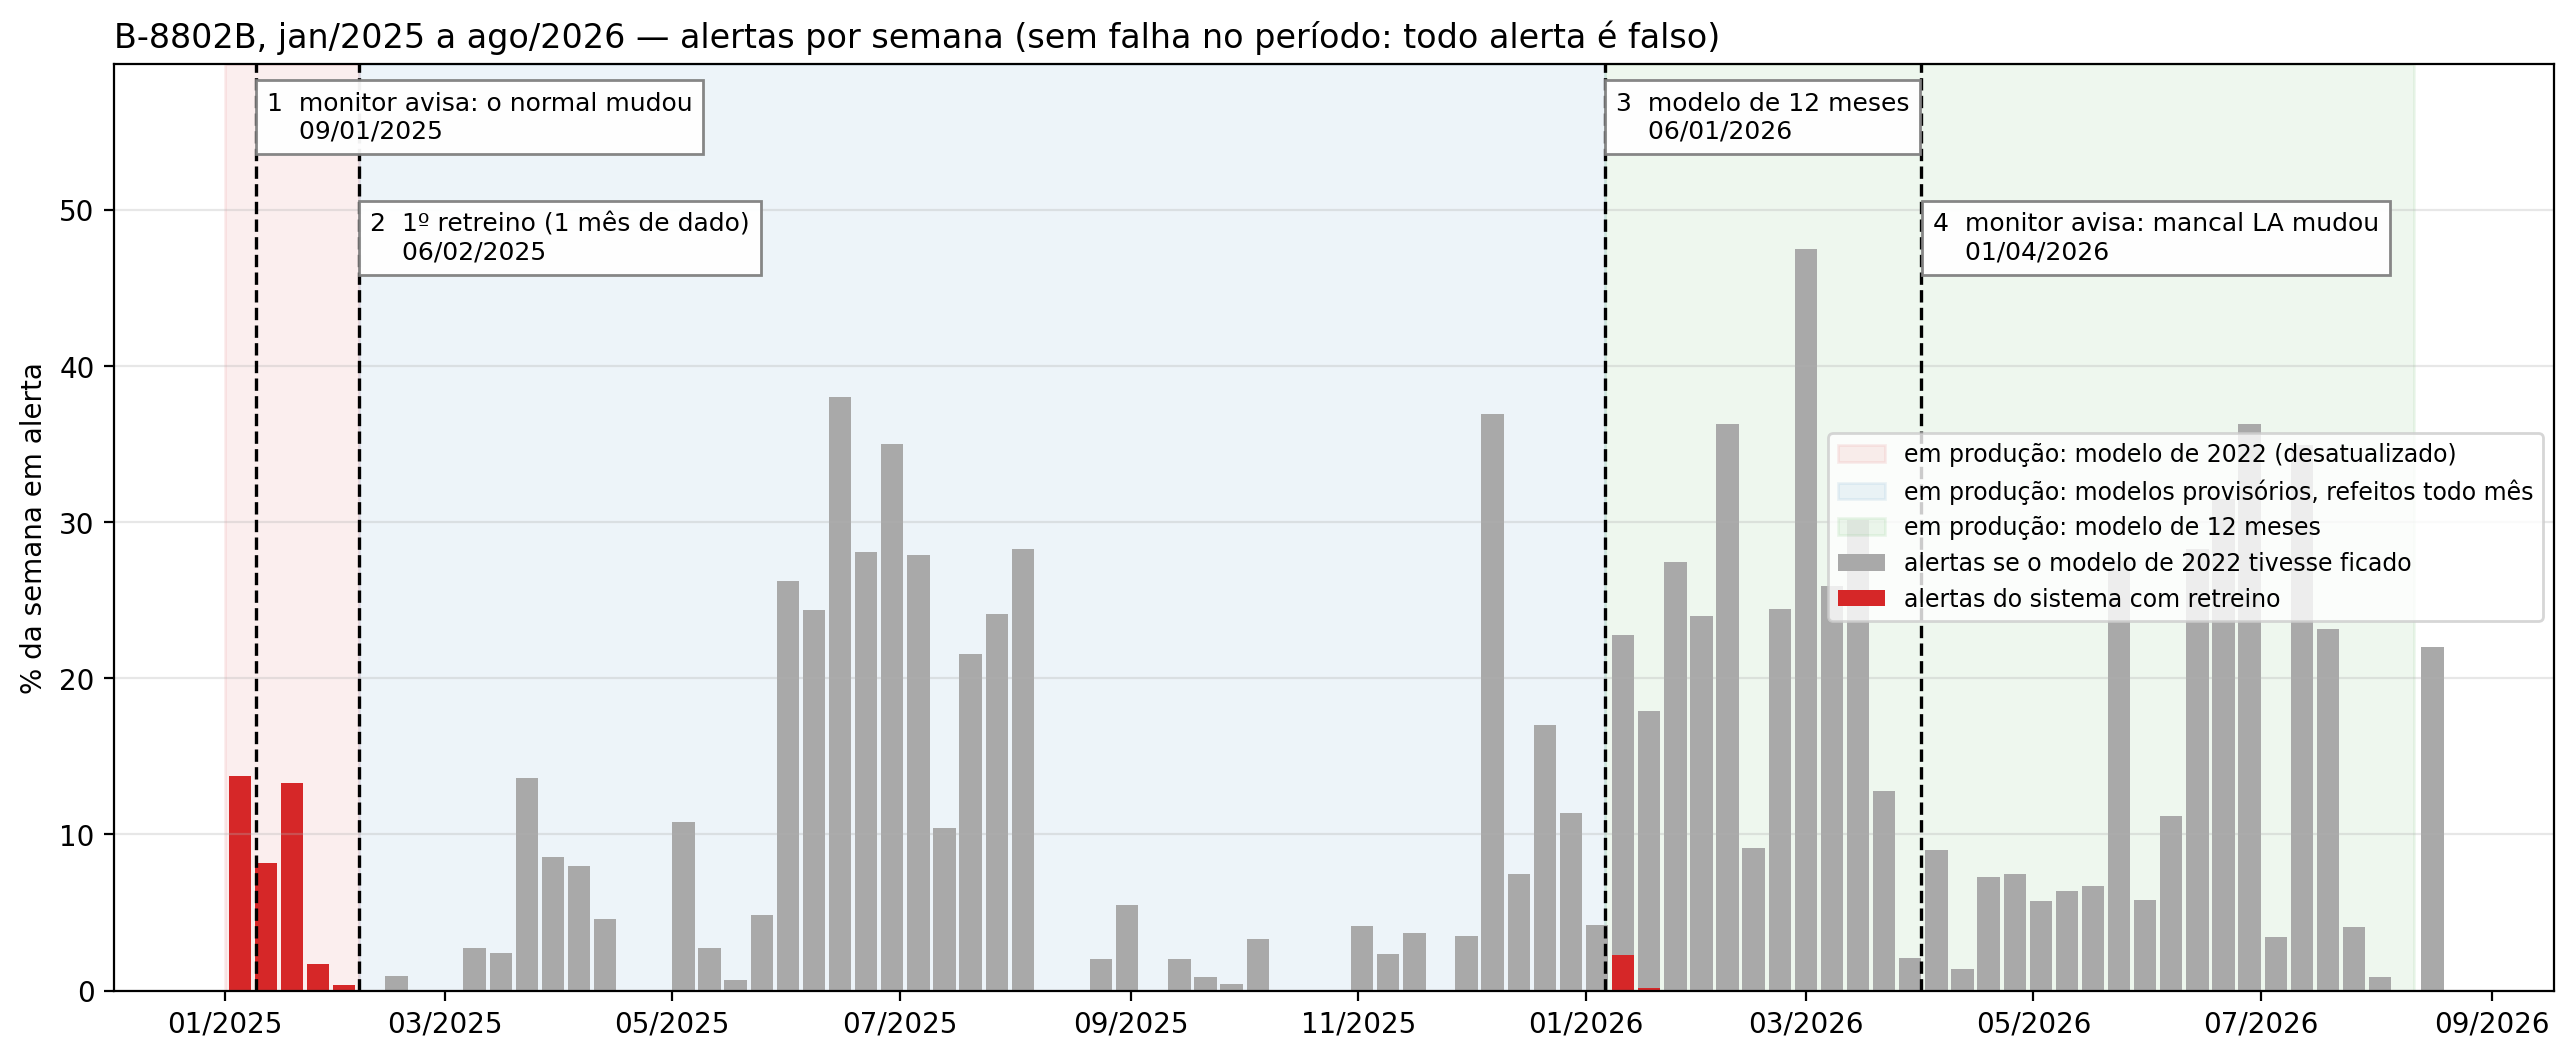

In [2]:
sem = lambda r: 100 * r["alerta"].groupby(pd.Grouper(freq="W")).mean()
s_ant, s_sis = sem(antigo), sem(sistema)
t_retreino, t_12 = agenda[1]["ini"], agenda[-1]["ini"]

fig, ax = plt.subplots(figsize=(13, 5.4))
ax.axvspan(raw.index.min(), t_retreino, color="tab:red", alpha=0.08, label="em produção: modelo de 2022 (desatualizado)")
ax.axvspan(t_retreino, t_12, color="tab:blue", alpha=0.08, label="em produção: modelos provisórios, refeitos todo mês")
ax.axvspan(t_12, FIM, color="tab:green", alpha=0.08, label="em produção: modelo de 12 meses")
ax.bar(s_ant.index, s_ant.values, width=6, color="darkgray", label="alertas se o modelo de 2022 tivesse ficado")
ax.bar(s_sis.index, s_sis.values, width=6, color="tab:red", label="alertas do sistema com retreino")
topo = max(s_ant.max(), s_sis.max()) * 1.25; ax.set_ylim(0, topo)
marcas = [(t_drift, "1", "monitor avisa: o normal mudou", 0.97), (t_retreino, "2", "1º retreino (1 mês de dado)", 0.84),
          (t_12, "3", "modelo de 12 meses", 0.97), (t_m8, "4", "monitor avisa: mancal LA mudou", 0.84)]
for t, n, txt, y in marcas:
    ax.axvline(t, color="black", linewidth=1.2, linestyle="--")
    ax.text(t + pd.Timedelta(days=3), topo * y, f"{n}  {txt}\n    {t:%d/%m/%Y}", va="top", fontsize=9,
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.95))
ax.set_ylabel("% da semana em alerta"); ax.grid(alpha=0.3, axis="y"); ax.legend(loc="center right", fontsize=8.5)
ax.set_title("B-8802B, jan/2025 a ago/2026 — alertas por semana (sem falha no período: todo alerta é falso)", loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y")); plt.tight_layout(); plt.show()

## Está bom?

In [3]:
depois = sistema[sistema.index >= t_retreino]
eps_dep = [e for e in eps if e["início"] >= t_retreino]
print(f"Se o modelo de 2022 tivesse ficado:  alerta em {100 * antigo['alerta'].mean():4.1f} % do tempo, {len(eps_antigo)} alertas falsos")
print(f"Com a política de retreino:          alerta em {100 * depois['alerta'].mean():4.2f} % do tempo depois do 1º retreino, "
      f"{len(eps_dep)} alertas ({', '.join(e['início'].strftime('%d/%m/%Y') for e in eps_dep)})")
print(f"Falha real de 2022 (o teste de que o modelo não ficou cego): todos os {int(resumo['aprovado'].sum())} modelos "
      f"alertam {resumo['falha_2022_dias'].min():.1f} a {resumo['falha_2022_dias'].max():.1f} dias antes")

Se o modelo de 2022 tivesse ficado:  alerta em 12.0 % do tempo, 269 alertas falsos
Com a política de retreino:          alerta em 0.04 % do tempo depois do 1º retreino, 2 alertas (10/01/2026, 17/01/2026)
Falha real de 2022 (o teste de que o modelo não ficou cego): todos os 12 modelos alertam 1.9 a 2.1 dias antes


**Sim, está bom.** Lendo a figura pelos números:

1. **09/01/2025 — o monitor avisa.** Depois do reparo de 2022 o equipamento passou a operar de outro jeito, e o modelo
   de 2022 começou a alertar sem motivo (barras vermelhas de janeiro).
2. **06/02/2025 — 1º retreino.** Com 1 mês de dado do normal novo entra um modelo novo, refeito todo mês. **Os alertas
   falsos param na hora.** Se o modelo de 2022 tivesse ficado, as barras cinza mostram o que teria acontecido: alertas o
   ano todo.
3. **06/01/2026 — modelo de 12 meses.** Fica fixo. Ele deu 2 alertas em jan/2026 (a verificar com a operação) e nenhum
   depois.
4. **01/04/2026 — o monitor avisa de novo:** a temperatura do mancal LA esfriou ~6 °C depois de uma parada da bomba em
   27/03. **Por que não houve retreino aqui?** Porque a política só retreina depois que a operação confirma o que
   mudou, e essa resposta ainda não veio. Enquanto isso o modelo continua sem alertar à toa, então não há urgência. Se
   a operação confirmar um normal novo, entra um modelo provisório 1 mês depois, como em 2025.

**E ele continua detectando falha?** Sim: todos os modelos que entraram em produção alertam ~2 dias antes da falha real
de 2022, que nenhum deles viu.

**O ponto fraco** é o 1º mês depois do aviso (janeiro/2025): o modelo antigo ainda está em produção e alerta à toa até o
retreino entrar. A política manda tratar esses alertas com ressalva a partir do aviso.

---

## Detalhes (para quem quiser conferir)

In [4]:
pd.DataFrame([{"modelo em produção": e["modelo"], "início": f"{e['início']:%d/%m/%Y %H:%M}", "horas de alerta": e["horas"],
               "sensor que mais pesou": e["sensor que mais pesou"]} for e in eps]).set_index("modelo em produção")

,início,horas de alerta,sensor que mais pesou
modelo em produção,,,
2022,01/01/2025 05:05,5.6,Vibração Bomba LA
2022,01/01/2025 17:25,6.3,Vibração Bomba LA
2022,04/01/2025 07:35,1.2,Vibração Bomba LA
2022,05/01/2025 13:00,3.2,Temperatura Bomba LA
2022,07/01/2025 16:05,0.1,Vibração Bomba LA
2022,08/01/2025 01:05,7.2,Vibração Bomba LA
2022,11/01/2025 02:05,2.3,Pressão Sucção
2022,12/01/2025 20:45,9.2,Temperatura Bomba LA
2022,15/01/2025 06:40,0.1,Pressão Descarga


In [5]:
resumo[["etapa", "treino_fim", "aprovado", "falha_2022_dias", "sintetica_h"]].rename(columns={
    "etapa": "meses de dado", "treino_fim": "entra em produção", "falha_2022_dias": "falha de 2022 (dias antes)",
    "sintetica_h": "falha simulada (h antes)"}).round(1).set_index("meses de dado")

,entra em produção,aprovado,falha de 2022 (dias antes),falha simulada (h antes)
meses de dado,,,,
1,2025-02-06,True,2.1,15.1
2,2025-03-06,True,1.9,12.5
3,2025-04-06,True,1.9,16.1
4,2025-05-06,True,2.1,27.7
5,2025-06-06,True,2.1,8.2
6,2025-07-06,True,2.1,10.2
7,2025-08-06,True,2.1,25.6
8,2025-09-06,True,2.1,23.2
9,2025-10-06,True,2.1,19.4
